## Goal

This notebook trains a CUDA-ready neural forecaster for market candles. The target is a sequence of future log returns, which is usually more stable than raw close-price regression for financial data.

Research scan used for the model choice:

| Model family | Strong point | Practical note for this repository |
|---|---|---|
| N-BEATS | Very strong univariate neural baseline and interpretable blocks. Paper: https://arxiv.org/abs/1905.10437 | Good fallback for a single target series, but less natural for OHLCV feature panels. |
| Temporal Fusion Transformer | Multi-horizon forecasting with static and known-future covariates. Paper: https://arxiv.org/abs/1912.09363 | Powerful when calendars, events, and known future inputs are available. More setup than needed for plain candles. |
| TimesNet | Converts temporal variation into 2D tensors and reports strong results across tasks. Paper: https://arxiv.org/abs/2210.02186 | Broad architecture, but heavier to implement and tune in one notebook. |
| TiDE | Fast dense encoder-decoder for long-term forecasting. Paper: https://arxiv.org/abs/2304.08424 | Excellent speed baseline, but less expressive for local patch patterns. |
| iTransformer | Inverts Transformer dimensions and is strong for multivariate time series. Paper: https://arxiv.org/abs/2310.06625 | A strong next candidate if we train across many related assets/features. |
| PatchTST | Patches the time axis, reduces attention cost, and reports strong long-horizon accuracy. Paper: https://arxiv.org/abs/2211.14730 | Selected here: efficient on long lookback windows and easy to train on one GPU. |

The implemented model is PatchTST-style: it tokenizes each feature history into temporal patches, encodes them with a shared Transformer, then mixes channel representations before predicting the future return path. The channel mixer is a practical addition for OHLCV data so volume, range, RSI, and volatility features can influence the target forecast.

## 1. Imports and project setup

In [1]:
from __future__ import annotations

import math
import random
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

PROJECT_ROOT

WindowsPath('C:/WorkPrograms/TimeAnalysis/research')

## 2. Experiment configuration

Defaults are intentionally conservative for a first GPU run. For a larger test, increase `input_length`, `prediction_length`, and the date range after the notebook runs end-to-end once.

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    pair: str = "BTC/USDT"
    timeframe: str = "5m"
    start: str = "2024-01-01"
    end: str = "2026-06-01"
    category: str = "spot"
    data_path: Path | None = None
    download_if_missing: bool = True

    target_column: str = "log_return_1"
    feature_columns: tuple[str, ...] = (
        "log_return_1",
        "log_return_3",
        "log_return_6",
        "log_return_12",
        "log_return_24",
        "log_return_48",
        "volatility_24",
        "volatility_96",
        "rsi_14",
        "range_ratio",
        "body_ratio",
        "volume_z_96",
        "close_to_sma_96",
        "close_to_sma_288",
    )

    input_length: int = 512
    prediction_length: int = 24
    train_ratio: float = 0.70
    validation_ratio: float = 0.15

    patch_length: int = 16
    stride: int = 8
    d_model: int = 128
    n_heads: int = 8
    n_layers: int = 4
    feedforward_multiplier: int = 4
    dropout: float = 0.15
    head_hidden_size: int = 256

    batch_size: int = 256
    epochs: int = 40
    learning_rate: float = 1e-4
    weight_decay: float = 1e-3
    directional_loss_weight: float = 0.10
    patience: int = 8
    gradient_clip_norm: float = 1.0
    num_workers: int = 0
    seed: int = 42
    use_amp: bool = True

    signal_threshold: float = 0.0005
    transaction_cost: float = 0.0006


config = ExperimentConfig()

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(config.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("high")

config

Device: cuda
CUDA device: NVIDIA GeForce RTX 3070 Laptop GPU


ExperimentConfig(pair='BTC/USDT', timeframe='5m', start='2024-01-01', end='2026-06-01', category='spot', data_path=None, download_if_missing=True, target_column='log_return_1', feature_columns=('log_return_1', 'log_return_3', 'log_return_6', 'log_return_12', 'log_return_24', 'log_return_48', 'volatility_24', 'volatility_96', 'rsi_14', 'range_ratio', 'body_ratio', 'volume_z_96', 'close_to_sma_96', 'close_to_sma_288'), input_length=512, prediction_length=24, train_ratio=0.7, validation_ratio=0.15, patch_length=16, stride=8, d_model=128, n_heads=8, n_layers=4, feedforward_multiplier=4, dropout=0.15, head_hidden_size=256, batch_size=256, epochs=40, learning_rate=0.0001, weight_decay=0.001, directional_loss_weight=0.1, patience=8, gradient_clip_norm=1.0, num_workers=0, seed=42, use_amp=True, signal_threshold=0.0005, transaction_cost=0.0006)

## 3. Load OHLCV candles

In [3]:
def pair_slug(pair: str) -> str:
    return pair.replace("/", "_").replace(":", "_")


def default_freqtrade_path(cfg: ExperimentConfig) -> Path:
    filename = f"{pair_slug(cfg.pair)}-{cfg.timeframe}.feather"
    return PROJECT_ROOT / "trading" / "freqtrade" / "user_data" / "data" / "bybit" / filename


def read_ohlcv_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".feather":
        return pd.read_feather(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".csv":
        return pd.read_csv(path)
    msg = f"Unsupported data file extension: {path}"
    raise ValueError(msg)


def load_candles(cfg: ExperimentConfig) -> pd.DataFrame:
    requested_path = cfg.data_path or default_freqtrade_path(cfg)
    if requested_path.exists():
        print(f"Loading candles from {requested_path}")
        return read_ohlcv_file(requested_path)

    if not cfg.download_if_missing:
        msg = f"No local data at {requested_path}. Set data_path or enable download_if_missing."
        raise FileNotFoundError(msg)

    from time_analysis.data_sources.bybit_public import download_bybit_ohlcv

    print(f"Downloading {cfg.pair} {cfg.timeframe} candles from Bybit")
    candles = download_bybit_ohlcv(
        pair=cfg.pair,
        timeframe=cfg.timeframe,
        start=cfg.start,
        end=cfg.end,
        category=cfg.category,
    )
    requested_path.parent.mkdir(parents=True, exist_ok=True)
    candles.reset_index(drop=True).to_feather(requested_path)
    print(f"Saved candles to {requested_path}")
    return candles


candles = load_candles(config)
candles["date"] = pd.to_datetime(candles["date"], utc=True)
candles = candles.sort_values("date").drop_duplicates("date").reset_index(drop=True)

print(candles.shape)
candles.tail()

Loading candles from C:\WorkPrograms\TimeAnalysis\research\trading\freqtrade\user_data\data\bybit\BTC_USDT-5m.feather
(254017, 6)


,date,open,high,low,close,volume
254012,2026-05-31 23:40:00+00:00,73572.3,73600.0,73520.6,73581.6,19.557906
254013,2026-05-31 23:45:00+00:00,73581.6,73677.3,73569.3,73677.3,16.465642
254014,2026-05-31 23:50:00+00:00,73677.3,73710.5,73673.7,73680.3,15.691554
254015,2026-05-31 23:55:00+00:00,73680.3,73723.2,73653.2,73683.6,12.099120
254016,2026-06-01 00:00:00+00:00,73683.6,73879.3,73652.8,73870.4,47.893129


## 4. Feature engineering

The model predicts future one-candle log returns for `prediction_length` steps. Cumulative predicted return over the horizon is used for directional metrics and a simple signal check.

In [4]:
def relative_strength_index(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    average_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    average_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    relative_strength = average_gain / average_loss.replace(0.0, np.nan)
    return (100.0 - (100.0 / (1.0 + relative_strength))).fillna(50.0)


def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    mean = series.rolling(window=window, min_periods=window).mean()
    std = series.rolling(window=window, min_periods=window).std(ddof=0)
    return ((series - mean) / std.replace(0.0, np.nan)).fillna(0.0)


def build_market_frame(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()
    for column in ["open", "high", "low", "close", "volume"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    close = df["close"].astype("float64")
    high = df["high"].astype("float64")
    low = df["low"].astype("float64")
    open_ = df["open"].astype("float64")
    volume = df["volume"].astype("float64")
    log_close = np.log(close.replace(0.0, np.nan))

    for lag in [1, 3, 6, 12, 24, 48]:
        df[f"log_return_{lag}"] = log_close.diff(lag)
    df["volatility_24"] = df["log_return_1"].rolling(24, min_periods=24).std(ddof=0)
    df["volatility_96"] = df["log_return_1"].rolling(96, min_periods=96).std(ddof=0)
    df["rsi_14"] = relative_strength_index(close, 14) / 100.0
    df["range_ratio"] = ((high - low) / close).replace([np.inf, -np.inf], np.nan)
    df["body_ratio"] = ((close - open_) / close).replace([np.inf, -np.inf], np.nan)
    df["volume_z_96"] = rolling_zscore(np.log1p(volume), 96)
    df["close_to_sma_96"] = (close / close.rolling(96, min_periods=96).mean()) - 1.0
    df["close_to_sma_288"] = (close / close.rolling(288, min_periods=288).mean()) - 1.0

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


market_frame = build_market_frame(candles)
required_columns = [*config.feature_columns, config.target_column]
missing_columns = [column for column in required_columns if column not in market_frame]
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

model_frame = market_frame.dropna(subset=required_columns).reset_index(drop=True)
print(model_frame.shape)
model_frame[["date", "close", config.target_column, "volatility_96", "rsi_14"]].tail()

(253730, 20)


,date,close,log_return_1,volatility_96,rsi_14
253725,2026-05-31 23:40:00+00:00,73581.6,0.000126,0.000721,0.343034
253726,2026-05-31 23:45:00+00:00,73677.3,0.001300,0.000733,0.419054
253727,2026-05-31 23:50:00+00:00,73680.3,0.000041,0.000732,0.421314
253728,2026-05-31 23:55:00+00:00,73683.6,0.000045,0.000732,0.423970
253729,2026-06-01 00:00:00+00:00,73870.4,0.002532,0.000774,0.549875


## 5. Chronological split and datasets

In [5]:
class WindowDataset(Dataset):
    def __init__(
        self,
        features: np.ndarray,
        target_scaled: np.ndarray,
        target_raw: np.ndarray,
        start_indices: np.ndarray,
        input_length: int,
        prediction_length: int,
    ) -> None:
        self.features = features.astype(np.float32, copy=False)
        self.target_scaled = target_scaled.astype(np.float32, copy=False)
        self.target_raw = target_raw.astype(np.float32, copy=False)
        self.start_indices = start_indices.astype(np.int64, copy=False)
        self.input_length = input_length
        self.prediction_length = prediction_length

    def __len__(self) -> int:
        return len(self.start_indices)

    def __getitem__(self, item: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        start = int(self.start_indices[item])
        context_end = start + self.input_length
        target_end = context_end + self.prediction_length
        x = self.features[start:context_end]
        y_scaled = self.target_scaled[context_end:target_end]
        y_raw = self.target_raw[context_end:target_end]
        return torch.from_numpy(x), torch.from_numpy(y_scaled), torch.from_numpy(y_raw)


def split_start_indices(n_rows: int, cfg: ExperimentConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray, int, int]:
    max_start = n_rows - cfg.input_length - cfg.prediction_length
    if max_start <= 0:
        msg = "Not enough rows for the selected input_length and prediction_length"
        raise ValueError(msg)

    starts = np.arange(max_start + 1)
    target_start = starts + cfg.input_length
    target_end = target_start + cfg.prediction_length
    train_cutoff = int(n_rows * cfg.train_ratio)
    validation_cutoff = int(n_rows * (cfg.train_ratio + cfg.validation_ratio))

    train_starts = starts[target_end <= train_cutoff]
    validation_starts = starts[(target_start >= train_cutoff) & (target_end <= validation_cutoff)]
    test_starts = starts[target_start >= validation_cutoff]
    return train_starts, validation_starts, test_starts, train_cutoff, validation_cutoff


feature_columns = list(config.feature_columns)
train_starts, validation_starts, test_starts, train_cutoff, validation_cutoff = split_start_indices(
    len(model_frame),
    config,
)

feature_scaler = StandardScaler()
target_scaler = StandardScaler()
feature_scaler.fit(model_frame.loc[: train_cutoff - 1, feature_columns])
target_scaler.fit(model_frame.loc[: train_cutoff - 1, [config.target_column]])

features_scaled = feature_scaler.transform(model_frame[feature_columns]).astype(np.float32)
target_scaled = target_scaler.transform(model_frame[[config.target_column]]).ravel().astype(np.float32)
target_raw = model_frame[config.target_column].to_numpy(dtype=np.float32)

train_dataset = WindowDataset(
    features_scaled,
    target_scaled,
    target_raw,
    train_starts,
    config.input_length,
    config.prediction_length,
)
validation_dataset = WindowDataset(
    features_scaled,
    target_scaled,
    target_raw,
    validation_starts,
    config.input_length,
    config.prediction_length,
)
test_dataset = WindowDataset(
    features_scaled,
    target_scaled,
    target_raw,
    test_starts,
    config.input_length,
    config.prediction_length,
)

loader_kwargs = {
    "batch_size": config.batch_size,
    "num_workers": config.num_workers,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": config.num_workers > 0,
}
train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True, **loader_kwargs)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

pd.Series(
    {
        "rows": len(model_frame),
        "train_rows_until": str(model_frame.loc[train_cutoff - 1, "date"]),
        "validation_rows_until": str(model_frame.loc[validation_cutoff - 1, "date"]),
        "train_windows": len(train_dataset),
        "validation_windows": len(validation_dataset),
        "test_windows": len(test_dataset),
        "features": len(feature_columns),
    }
)

rows                                        253730
train_rows_until         2025-09-09 16:45:00+00:00
validation_rows_until    2026-01-19 20:20:00+00:00
train_windows                               177076
validation_windows                           38036
test_windows                                 38037
features                                        14
dtype: object

## 6. PatchTST-style model

In [6]:
class RevIN(nn.Module):
    def __init__(self, num_features: int, eps: float = 1e-5, affine: bool = True) -> None:
        super().__init__()
        self.eps = eps
        self.affine = affine
        if affine:
            self.weight = nn.Parameter(torch.ones(1, 1, num_features))
            self.bias = nn.Parameter(torch.zeros(1, 1, num_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=1, keepdim=True).detach()
        std = x.std(dim=1, keepdim=True, unbiased=False).add(self.eps).detach()
        x = (x - mean) / std
        if self.affine:
            x = x * self.weight + self.bias
        return x


class PatchTSTForecaster(nn.Module):
    def __init__(
        self,
        num_features: int,
        input_length: int,
        prediction_length: int,
        patch_length: int,
        stride: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        feedforward_multiplier: int,
        dropout: float,
        head_hidden_size: int,
    ) -> None:
        super().__init__()
        if input_length < patch_length:
            raise ValueError("input_length must be at least patch_length")
        self.num_features = num_features
        self.patch_length = patch_length
        self.stride = stride
        self.num_patches = 1 + (input_length - patch_length) // stride

        self.revin = RevIN(num_features)
        self.patch_projection = nn.Linear(patch_length, d_model)
        self.position_embedding = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * feedforward_multiplier,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.channel_projection = nn.Sequential(
            nn.Linear(self.num_patches * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(num_features * d_model, head_hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_size, prediction_length),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x = self.revin(x)
        patches = x.permute(0, 2, 1).unfold(dimension=-1, size=self.patch_length, step=self.stride)
        z = self.patch_projection(patches)
        z = z.reshape(batch_size * self.num_features, self.num_patches, -1)
        z = z + self.position_embedding
        z = self.encoder(z)
        z = z.reshape(batch_size, self.num_features, self.num_patches * z.shape[-1])
        z = self.channel_projection(z)
        return self.head(z.reshape(batch_size, -1))


model = PatchTSTForecaster(
    num_features=len(feature_columns),
    input_length=config.input_length,
    prediction_length=config.prediction_length,
    patch_length=config.patch_length,
    stride=config.stride,
    d_model=config.d_model,
    n_heads=config.n_heads,
    n_layers=config.n_layers,
    feedforward_multiplier=config.feedforward_multiplier,
    dropout=config.dropout,
    head_hidden_size=config.head_hidden_size,
).to(DEVICE)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Parameters: {parameter_count:,}")

Parameters: 2,300,852


C:\Users\qweqw\AppData\Local\Temp\ipykernel_36908\943349741.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


## 7. Training loop

In [7]:
target_mean = torch.tensor(float(target_scaler.mean_[0]), device=DEVICE)
target_std = torch.tensor(float(target_scaler.scale_[0]), device=DEVICE)
criterion = nn.SmoothL1Loss(beta=0.5)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)
amp_enabled = bool(config.use_amp and DEVICE.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)


def batch_loss(prediction: torch.Tensor, target_scaled_batch: torch.Tensor, target_raw_batch: torch.Tensor) -> torch.Tensor:
    regression_loss = criterion(prediction, target_scaled_batch)
    if config.directional_loss_weight <= 0:
        return regression_loss

    prediction_raw_sum = (prediction * target_std + target_mean).sum(dim=1)
    target_direction = (target_raw_batch.sum(dim=1) > 0).float()
    direction_scale = target_std * math.sqrt(config.prediction_length) + 1e-8
    direction_loss = F.binary_cross_entropy_with_logits(
        prediction_raw_sum / direction_scale,
        target_direction,
    )
    return regression_loss + (config.directional_loss_weight * direction_loss)


def train_one_epoch(model: nn.Module, loader: DataLoader) -> float:
    model.train()
    total_loss = 0.0
    total_items = 0
    progress = tqdm(loader, desc="train", leave=False)
    for x, y_scaled, y_raw in progress:
        x = x.to(DEVICE, non_blocking=True)
        y_scaled = y_scaled.to(DEVICE, non_blocking=True)
        y_raw = y_raw.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
            prediction = model(x)
            loss = batch_loss(prediction, y_scaled, y_raw)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        batch_items = len(x)
        total_loss += float(loss.detach().cpu()) * batch_items
        total_items += batch_items
        progress.set_postfix(loss=total_loss / max(total_items, 1))
    return total_loss / total_items


@torch.no_grad()
def evaluate_loss(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    total_items = 0
    for x, y_scaled, y_raw in loader:
        x = x.to(DEVICE, non_blocking=True)
        y_scaled = y_scaled.to(DEVICE, non_blocking=True)
        y_raw = y_raw.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
            prediction = model(x)
            loss = batch_loss(prediction, y_scaled, y_raw)
        batch_items = len(x)
        total_loss += float(loss.detach().cpu()) * batch_items
        total_items += batch_items
    return total_loss / total_items


def fit_model(model: nn.Module) -> pd.DataFrame:
    best_validation_loss = math.inf
    best_state = None
    stale_epochs = 0
    rows: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        train_loss = train_one_epoch(model, train_loader)
        validation_loss = evaluate_loss(model, validation_loader)
        scheduler.step(validation_loss)
        rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validation_loss": validation_loss,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )
        print(
            f"epoch={epoch:03d} train={train_loss:.6f} "
            f"validation={validation_loss:.6f} lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= config.patience:
                print(f"Early stopping after {epoch} epochs")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return pd.DataFrame(rows)


history = fit_model(model)
history.tail()

train:   0%|          | 0/691 [00:00<?, ?it/s]

epoch=001 train=0.512205 validation=0.431835 lr=1.00e-04


train:   0%|          | 0/691 [00:00<?, ?it/s]

epoch=002 train=0.510655 validation=0.435421 lr=1.00e-04


train:   0%|          | 0/691 [00:00<?, ?it/s]

...

train:   0%|          | 0/691 [00:00<?, ?it/s]

epoch=008 train=0.470537 validation=0.458144 lr=5.00e-05


train:   0%|          | 0/691 [00:00<?, ?it/s]

epoch=009 train=0.468075 validation=0.458065 lr=2.50e-05
Early stopping after 9 epochs


,epoch,train_loss,validation_loss,learning_rate
4,5,0.480148,0.451203,0.000050
5,6,0.475428,0.452310,0.000050
6,7,0.472889,0.455506,0.000050
7,8,0.470537,0.458144,0.000050
8,9,0.468075,0.458065,0.000025


## 8. Save checkpoint

In [8]:
checkpoint_dir = PROJECT_ROOT / "research" / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / "patchtst_cuda_forecaster.pt"
config_dict = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in asdict(config).items()
}
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": config_dict,
        "feature_columns": feature_columns,
        "feature_scaler_mean": feature_scaler.mean_,
        "feature_scaler_scale": feature_scaler.scale_,
        "target_scaler_mean": target_scaler.mean_,
        "target_scaler_scale": target_scaler.scale_,
        "history": history.to_dict(orient="list"),
    },
    checkpoint_path,
)
checkpoint_path

WindowsPath('C:/WorkPrograms/TimeAnalysis/research/research/checkpoints/patchtst_cuda_forecaster.pt')

## 9. Evaluate on the large holdout interval

In [9]:
@torch.no_grad()
def predict_loader(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    predictions: list[np.ndarray] = []
    actuals: list[np.ndarray] = []
    for x, _, y_raw in tqdm(loader, desc="predict"):
        x = x.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
            prediction_scaled = model(x)
        prediction_raw = prediction_scaled.float().cpu().numpy() * target_scaler.scale_[0] + target_scaler.mean_[0]
        predictions.append(prediction_raw)
        actuals.append(y_raw.numpy())
    return np.concatenate(predictions), np.concatenate(actuals)


def safe_auc(actual_direction: np.ndarray, score: np.ndarray) -> float:
    try:
        return float(roc_auc_score(actual_direction, score))
    except ValueError:
        return float("nan")


def forecast_metrics(prediction_raw: np.ndarray, actual_raw: np.ndarray, cfg: ExperimentConfig) -> pd.Series:
    predicted_cumulative = prediction_raw.sum(axis=1)
    actual_cumulative = actual_raw.sum(axis=1)
    predicted_direction = predicted_cumulative > 0
    actual_direction = actual_cumulative > 0
    signal = np.where(
        predicted_cumulative > cfg.signal_threshold,
        1.0,
        np.where(predicted_cumulative < -cfg.signal_threshold, -1.0, 0.0),
    )
    strategy_log_return = signal * actual_cumulative - np.abs(signal) * cfg.transaction_cost
    active_mask = signal != 0

    return pd.Series(
        {
            "step_mae": mean_absolute_error(actual_raw.ravel(), prediction_raw.ravel()),
            "step_rmse": math.sqrt(mean_squared_error(actual_raw.ravel(), prediction_raw.ravel())),
            "cumulative_mae": mean_absolute_error(actual_cumulative, predicted_cumulative),
            "cumulative_rmse": math.sqrt(mean_squared_error(actual_cumulative, predicted_cumulative)),
            "directional_accuracy": np.mean(predicted_direction == actual_direction),
            "directional_auc": safe_auc(actual_direction.astype(int), predicted_cumulative),
            "signal_coverage": np.mean(active_mask),
            "active_signal_hit_rate": np.mean(np.sign(signal[active_mask]) == np.sign(actual_cumulative[active_mask])) if active_mask.any() else np.nan,
            "mean_strategy_log_return": np.mean(strategy_log_return),
            "total_strategy_return": np.exp(np.sum(strategy_log_return)) - 1.0,
            "buy_and_hold_return_on_test_events": np.exp(np.sum(actual_cumulative)) - 1.0,
        }
    )


test_prediction_raw, test_actual_raw = predict_loader(model, test_loader)
metrics = forecast_metrics(test_prediction_raw, test_actual_raw, config)
metrics

predict:   0%|          | 0/149 [00:00<?, ?it/s]

step_mae                              0.000956
step_rmse                             0.001528
cumulative_mae                        0.004813
cumulative_rmse                       0.007224
directional_accuracy                  0.518101
directional_auc                       0.516720
signal_coverage                       0.413729
active_signal_hit_rate                0.511089
mean_strategy_log_return             -0.000291
total_strategy_return                -0.999984
buy_and_hold_return_on_test_events   -0.996134
dtype: float64

## 10. Visual diagnostics

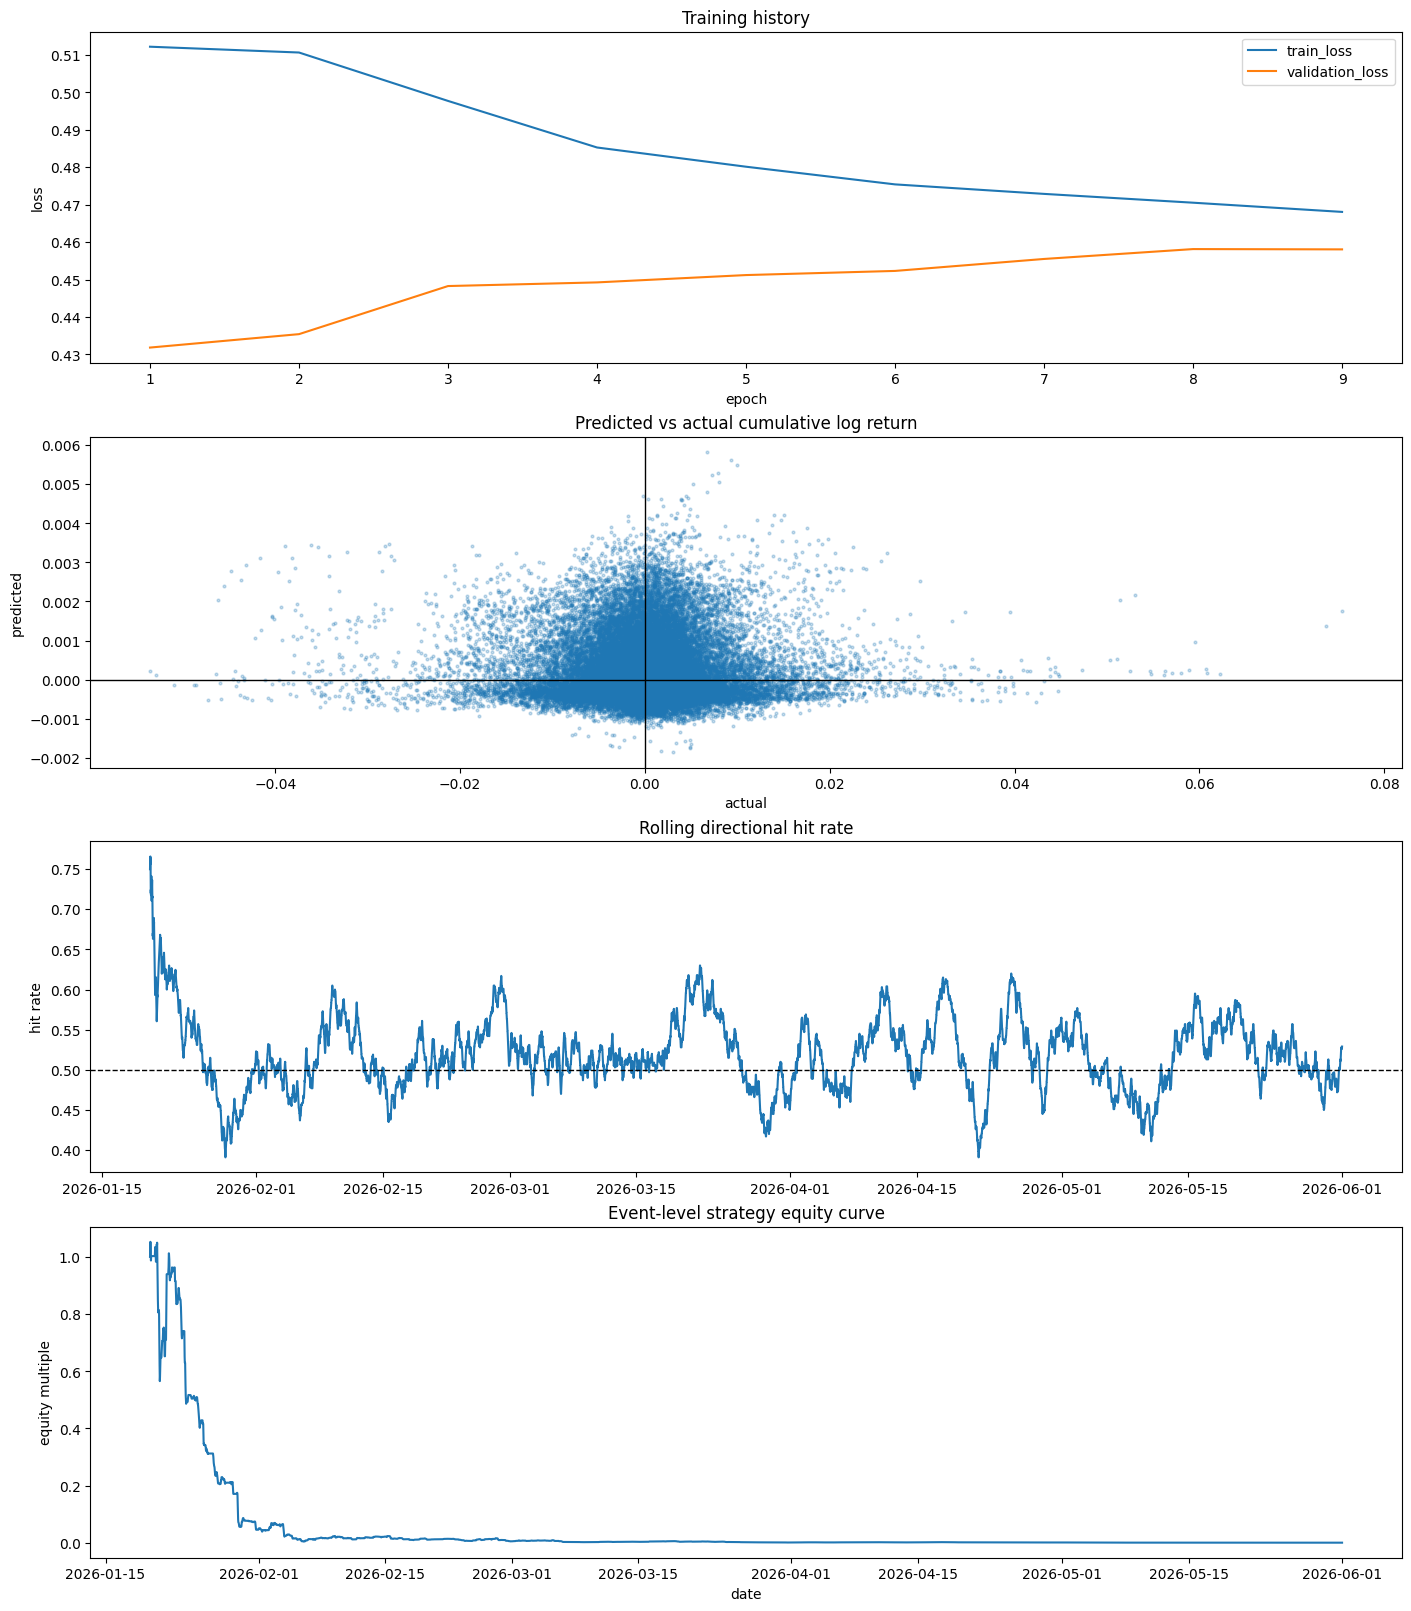

In [10]:
prediction_dates = model_frame.loc[
    test_starts + config.input_length + config.prediction_length - 1,
    "date",
].reset_index(drop=True)
predicted_cumulative = test_prediction_raw.sum(axis=1)
actual_cumulative = test_actual_raw.sum(axis=1)
signal = np.where(
    predicted_cumulative > config.signal_threshold,
    1.0,
    np.where(predicted_cumulative < -config.signal_threshold, -1.0, 0.0),
)
strategy_log_return = signal * actual_cumulative - np.abs(signal) * config.transaction_cost
equity_curve = np.exp(np.cumsum(strategy_log_return))
rolling_hit_rate = (
    pd.Series(np.sign(predicted_cumulative) == np.sign(actual_cumulative))
    .rolling(1000, min_periods=100)
    .mean()
)

fig, axes = plt.subplots(4, 1, figsize=(14, 16), constrained_layout=True)
history.plot(x="epoch", y=["train_loss", "validation_loss"], ax=axes[0])
axes[0].set_title("Training history")
axes[0].set_ylabel("loss")

axes[1].scatter(actual_cumulative, predicted_cumulative, s=4, alpha=0.25)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set_title("Predicted vs actual cumulative log return")
axes[1].set_xlabel("actual")
axes[1].set_ylabel("predicted")

axes[2].plot(prediction_dates, rolling_hit_rate)
axes[2].axhline(0.5, color="black", linewidth=1, linestyle="--")
axes[2].set_title("Rolling directional hit rate")
axes[2].set_ylabel("hit rate")

axes[3].plot(prediction_dates, equity_curve)
axes[3].set_title("Event-level strategy equity curve")
axes[3].set_ylabel("equity multiple")
axes[3].set_xlabel("date")

plt.show()

## 11. Export predictions for deeper checks

The simple event-level curve above uses overlapping prediction horizons, so treat it as a model diagnostic. A real trading decision should be checked in the repository's Freqtrade or signal backtesting pipeline with non-overlapping execution rules, fees, slippage, and position sizing.

In [11]:
prediction_frame = pd.DataFrame(
    {
        "date": prediction_dates,
        "predicted_cumulative_log_return": predicted_cumulative,
        "actual_cumulative_log_return": actual_cumulative,
        "signal": signal,
        "strategy_log_return": strategy_log_return,
    }
)
prediction_path = PROJECT_ROOT / "research" / "patchtst_test_predictions.csv"
prediction_frame.to_csv(prediction_path, index=False)
print(f"Saved predictions to {prediction_path}")
prediction_frame.tail()

Saved predictions to C:\WorkPrograms\TimeAnalysis\research\research\patchtst_test_predictions.csv


,date,predicted_cumulative_log_return,actual_cumulative_log_return,signal,strategy_log_return
38032,2026-05-31 23:40:00+00:00,-0.000430,-0.002247,0.0,-0.0
38033,2026-05-31 23:45:00+00:00,-0.000326,-0.002137,0.0,-0.0
38034,2026-05-31 23:50:00+00:00,-0.000348,-0.002375,0.0,-0.0
38035,2026-05-31 23:55:00+00:00,-0.000297,-0.002784,0.0,-0.0
38036,2026-06-01 00:00:00+00:00,-0.000175,0.001978,0.0,0.0


## Scaling notes

- For a stronger long-context run, try `input_length=1024` or `2048`, `d_model=192`, and `n_layers=6` if GPU memory allows it.
- Keep `num_workers=0` on Windows if multiprocessing causes notebook issues. Increase it on Linux for faster input pipelines.
- If the model underfits, increase `epochs` and `d_model`. If validation loss diverges, lower `learning_rate` to `5e-5` and increase dropout.
- If you later train many correlated assets together, iTransformer is the next architecture worth adding because it models multivariate dependencies directly.